In [12]:
#Part a) EDA
# i)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path="penguins.csv"
df = pd.read_csv(data_path)

print (f"Shape: {df.shape}")
print (f"Data types:\n{df.dtypes}")
print ("\n ================= Describe =================\n")
print(df.describe())



Shape: (344, 8)
Data types:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object

 ================= Describe =================

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   

In [13]:
print (f"Adelie Penguings: {df['species'].value_counts()['Adelie']}")
print (f"Gentoo Penguings: {df['species'].value_counts()['Gentoo']}")
print (f"Chinstrap Penguings: {df['species'].value_counts()['Chinstrap']}\n")

print(f"Penguings in Torgersen: {df['island'].value_counts()['Torgersen']}")
print(f"Penguings in Biscoe: {df['island'].value_counts()['Biscoe']}")
print(f"Penguings in Dream: {df['island'].value_counts()['Dream']}")



Adelie Penguings: 152
Gentoo Penguings: 124
Chinstrap Penguings: 68

Penguings in Torgersen: 52
Penguings in Biscoe: 168
Penguings in Dream: 124


In [14]:
# ii)
missing_values = []
for column in df.columns:
    missing_values.append(df[column].isna().sum())
    print(f"Missing values in {column}: {missing_values[-1]}")

morphological_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_cleaned = df.dropna(subset=morphological_features)
print(f"\nRemaning Penguins after removing missing data: {len(df_cleaned)}")


Missing values in species: 0
Missing values in island: 0
Missing values in bill_length_mm: 2
Missing values in bill_depth_mm: 2
Missing values in flipper_length_mm: 2
Missing values in body_mass_g: 2
Missing values in sex: 11
Missing values in year: 0

Remaning Penguins after removing missing data: 342


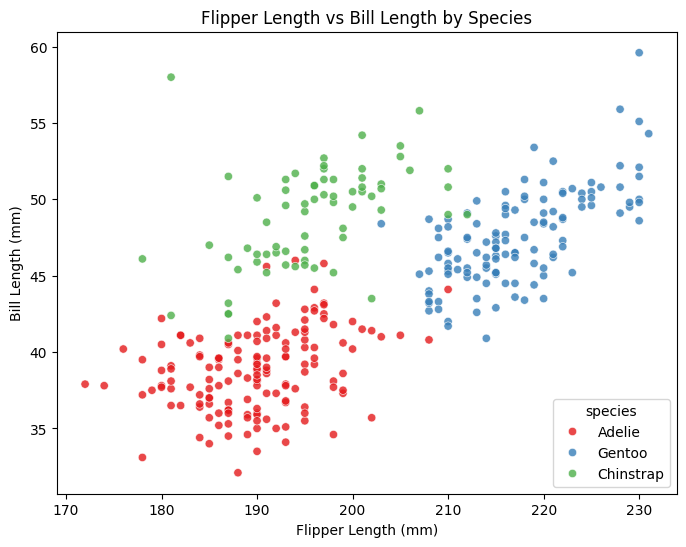

In [15]:
# iii)
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df, 
    x='flipper_length_mm', 
    y='bill_length_mm', 
    hue='species',
    palette='Set1',
    alpha=0.8
)

plt.title("Flipper Length vs Bill Length by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Length (mm)")

# Show the plot
plt.show()

There are 3 clearly defined blobs. However, Adelie and Chinstrap are somewhat similar and have overlaping points.

In [23]:
# b)
# i)
df_morphological = df_cleaned[morphological_features]
print (f"New shape {df_morphological.shape}")

New shape (342, 4)


ii) Standardizing the data is very important for the computation of Euclidian distance. If the unit of measurement are very different, different features will not be comparable since the ones with larger numbers will completely dominate the computation making our algorithm essentially ignore features with small numbers.

In [24]:
# iii)
df_standardized = df_morphological.copy()

for feature in morphological_features:
    mean_val = df[feature].mean()
    std_val = df[feature].std()
    
    # z = (x - µ) / σ
    df_standardized[feature] = (df[feature] - mean_val) / std_val

print("=== After Standardization ===")
for feature in morphological_features:
    post_mean = df_standardized[feature].mean()
    post_std = df_standardized[feature].std()
    print(f"{feature}:")
    print(f"  Resulting Mean: {post_mean:.6f}")
    print(f"  Resulting Std Dev: {post_std:.6f}\n")
    print(f"  Number of NaN values: {df_standardized[feature].isna().sum()}")

=== After Standardization ===
bill_length_mm:
  Resulting Mean: 0.000000
  Resulting Std Dev: 1.000000

  Number of NaN values: 0
bill_depth_mm:
  Resulting Mean: 0.000000
  Resulting Std Dev: 1.000000

  Number of NaN values: 0
flipper_length_mm:
  Resulting Mean: -0.000000
  Resulting Std Dev: 1.000000

  Number of NaN values: 0
body_mass_g:
  Resulting Mean: 0.000000
  Resulting Std Dev: 1.000000

  Number of NaN values: 0


Final Inertia (J): 378.2832


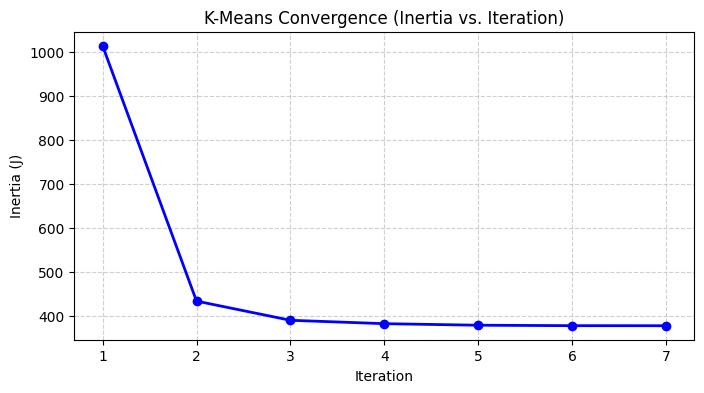

In [28]:
def kmeans(X, k, max_iter=100, seed=0):
    X = np.asarray(X)
    N, D = X.shape
    
    # Initialization
    np.random.seed(seed)
    initial_indices = np.random.choice(N, size=k, replace=False)
    centroids = X[initial_indices].copy()
    
    labels = np.full(N, -1)
    loss_history = []  # To track inertia at each iteration
    
    for iteration in range(max_iter):
        # 1. Assignment Step
        distances = np.sum((X[:, np.newaxis] - centroids) ** 2, axis=2)
        new_labels = np.argmin(distances, axis=1)
        
        # Calculate inertia for this step and save to history
        inertia = np.sum(np.min(distances, axis=1))
        loss_history.append(inertia)
        
        # 2. Convergence Check
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        
        # 3. Update Step
        for c in range(k):
            cluster_points = X[labels == c]
            if len(cluster_points) > 0:
                centroids[c] = cluster_points.mean(axis=0)
                
    return centroids, labels, loss_history[-1], loss_history

X_penguins = df_standardized[morphological_features].values
centroids, labels, final_inertia, loss_history = kmeans(X_penguins, k=3, seed=42)

print(f"Final Inertia (J): {final_inertia:.4f}")
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', color='b', linewidth=2)
plt.title("K-Means Convergence (Inertia vs. Iteration)")
plt.xlabel("Iteration")
plt.ylabel("Inertia (J)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, len(loss_history) + 1))
plt.show()

In [29]:
# d)
# i)
X_penguins = df_standardized[morphological_features].values
centroids, labels, final_inertia, loss_history = kmeans(X_penguins, k=3, seed=42)

print(f"Final Inertia (J): {final_inertia:.4f}")

Final Inertia (J): 378.2832


In [ ]:
# ii)df_cleaned['cluster'] = labels
cross_tab = pd.crosstab(df_cleaned['cluster'], df_cleaned['species'])

majority_counts = cross_tab.max(axis=1)
total_correct_majority = majority_counts.sum()
total_penguins = len(df_cleaned)
purity_fraction = total_correct_majority / total_penguins

print("=== Purity Report ===")
print(f"Majority counts per cluster:\n{majority_counts}\n")
print(f"Purity Fraction: {total_correct_majority} / {total_penguins} = {100*purity_fraction:.2f}%")

=== Purity Report ===
Majority counts per cluster:
cluster
0    123
1    127
2     63
dtype: int64

Purity Fraction: 313 / 342 = 91.52%


In [ ]:
# iii)
df_orig = df.dropna(subset=morphological_features)

means = np.array([df_orig[f].mean() for f in morphological_features])
stds = np.array([df_orig[f].std() for f in morphological_features])

centroids_original_units = (centroids * stds) + means

cluster_profiles = pd.DataFrame(
    centroids_original_units, 
    columns=morphological_features,
    index=[f"Cluster {i}" for i in range(len(centroids))]
)

# Display the table
print("=== Cluster Profiles in Original Units ===")
print(cluster_profiles.round(2))

=== Cluster Profiles in Original Units ===
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
Cluster 0           47.50          14.98             217.19      5076.02
Cluster 1           38.21          18.11             188.40      3584.66
Cluster 2           47.53          18.76             196.90      3902.01


Cluster 0 groups penguins with large shallow bills, large flippers, and large mass.

Cluster 1 groups penguins with short deep bills, short flippers, and small mass.

Cluster 2 groups penguins with large deep bills, intermidiate flippers, and intermidiate mass.

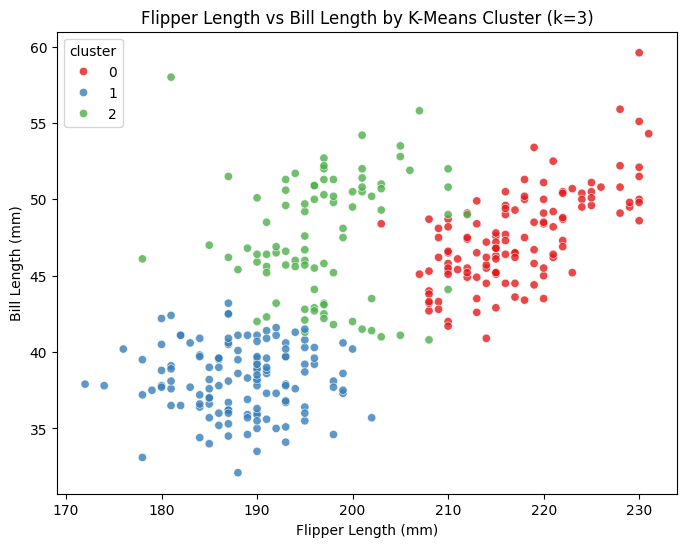

In [41]:
# iv)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_cleaned, 
    x='flipper_length_mm', 
    y='bill_length_mm', 
    hue='cluster',
    palette='Set1',  # Distinct color palette from the species plot
    alpha=0.8
)

plt.title("Flipper Length vs Bill Length by K-Means Cluster (k=3)")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Length (mm)")

plt.show()

The scatter plot looks very similar to the one in part a) iii). It mostly differs from it regarding cluster 2 (Chinstrap penguins) as the predictions about penguins in between two species were usually classified as Chinstrap rather than Adelie or Gentoo.

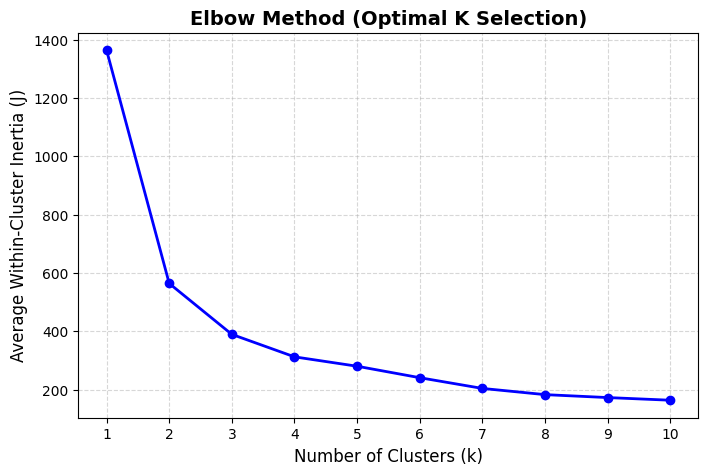

In [48]:
# e)
# i)
X_penguins = df_standardized[morphological_features].values
final_inertia_list = []
for k in range (1,11):
    average_final_inertia=0
    for i in range(1,11):
        centroids, labels, final_inertia, loss_history = kmeans(X_penguins, k=k, seed=i)
        average_final_inertia += final_inertia
    final_inertia_list.append(average_final_inertia/10)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), final_inertia_list, marker='o', color='b', linewidth=2, markersize=6)
plt.title("Elbow Method (Optimal K Selection)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Average Within-Cluster Inertia (J)", fontsize=12)
plt.xticks(range(1, 11))  # Ensure every k value from 1 to 10 is ticked
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The curve has very significant drops (100+) from 1 to 2 and from 2 to 3, after that the drops become much smaller and hardly decrease J in comparison to the first 2. Since we have 3 species and an elbow at 3, our prediction is consistent.

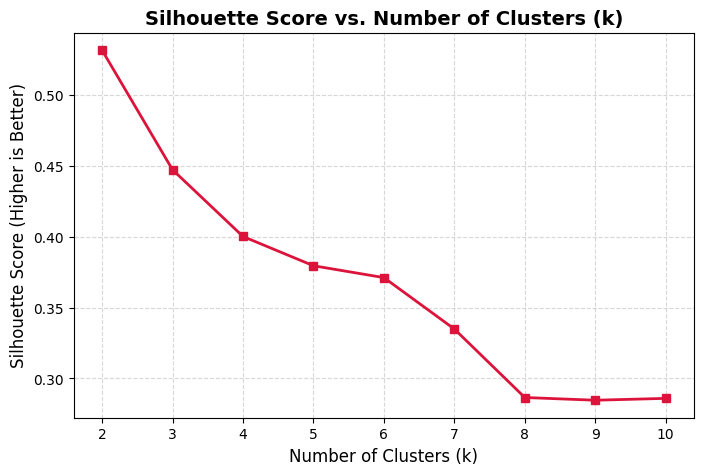

In [ ]:
# f)
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    best_inertia = float('inf')
    best_labels = None
    
    for seed in range(1, 11):
        centroids, labels, final_inertia, loss_history = kmeans(X_penguins, k=k, seed=seed)
        
        # lowest inertia
        if final_inertia < best_inertia:
            best_inertia = final_inertia
            best_labels = labels
            
    score = silhouette_score(X_penguins, best_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='s', color='crimson', linewidth=2, markersize=6)

plt.title("Silhouette Score vs. Number of Clusters (k)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score (Higher is Better)", fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

K=2 maximizes silhouette, which disagree with the elbow k=3 from last question. I would trust the elbow more in this case since the very first plot already indicated that there was some overlap between species, which is heavely punished by silhouette computation.

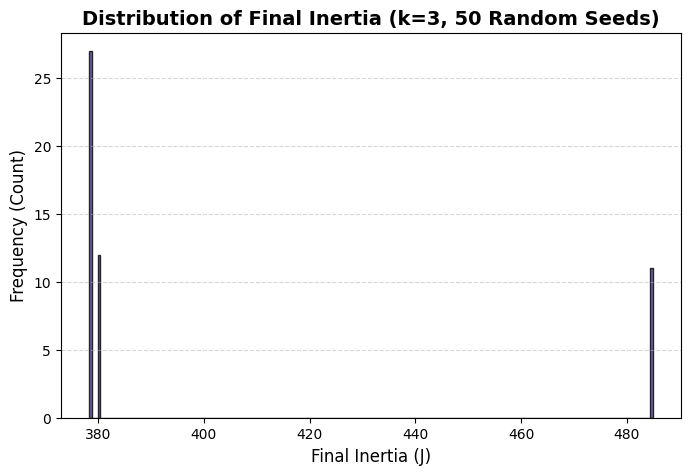

In [54]:
# g)
final_inertias = []

for seed in range(1, 51):
    centroids, labels, final_inertia, loss_history = kmeans(X_penguins, k=3, seed=seed)
    final_inertias.append(final_inertia)

plt.figure(figsize=(8, 5))

plt.hist(final_inertias, bins=200, color='darkslateblue', edgecolor='black', alpha=0.8)

plt.title("Distribution of Final Inertia (k=3, 50 Random Seeds)", fontsize=14, fontweight='bold')
plt.xlabel("Final Inertia (J)", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.show()

Most seeds are able to find the global minimum of the function, however, some seeds get trapped into a very high value (480+) making the plot about very significantly wide.

Best Seed (Lowest Inertia: 378.28): Seed 2
Worst Seed (Highest Inertia: 484.88): Seed 1


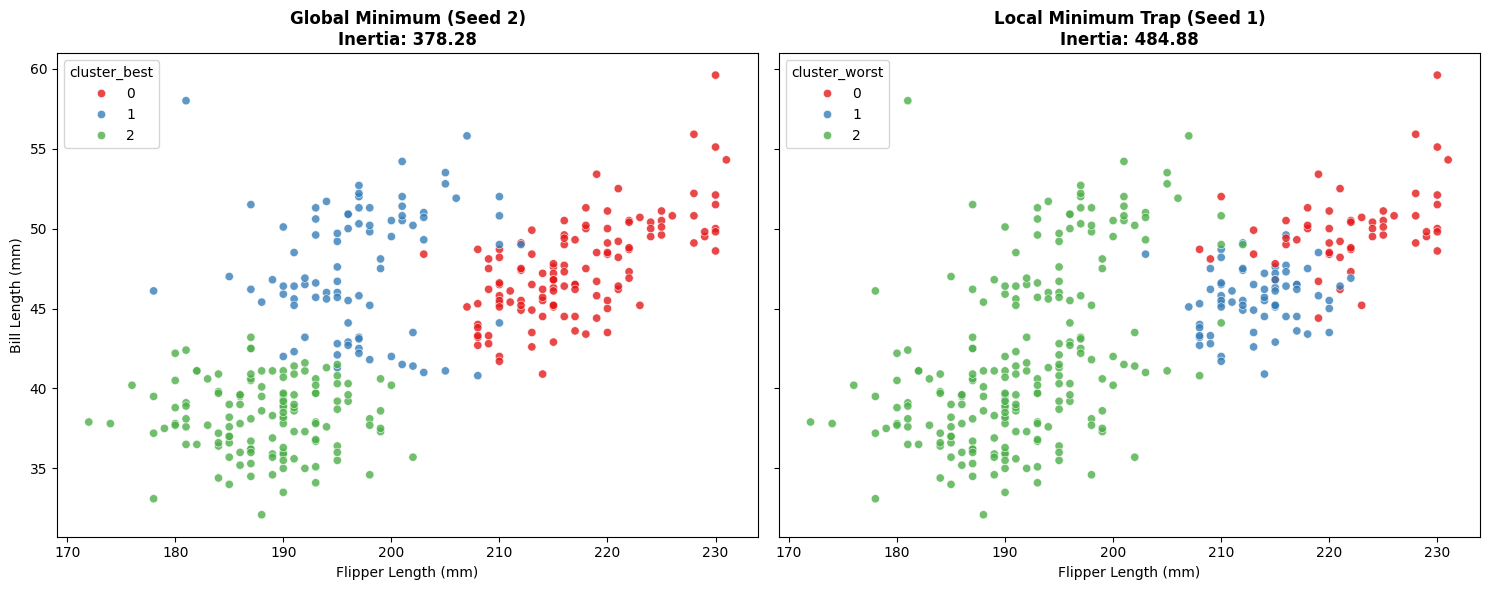

In [56]:
inertia_arr = np.array(final_inertias)
seeds = np.arange(1, 51)

# Find the seeds corresponding to the lowest and highest inertia
best_seed = seeds[np.argmin(inertia_arr)]
worst_seed = seeds[np.argmax(inertia_arr)]

print(f"Best Seed (Lowest Inertia: {np.min(inertia_arr):.2f}): Seed {best_seed}")
print(f"Worst Seed (Highest Inertia: {np.max(inertia_arr):.2f}): Seed {worst_seed}")

_, best_labels, _, _ = kmeans(X_penguins, k=3, seed=best_seed)
_, worst_labels, _, _ = kmeans(X_penguins, k=3, seed=worst_seed)

df_cleaned['cluster_best'] = best_labels
df_cleaned['cluster_worst'] = worst_labels

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# best clustering
sns.scatterplot(
    data=df_cleaned, 
    x='flipper_length_mm', 
    y='bill_length_mm', 
    hue='cluster_best', 
    palette='Set1', 
    alpha=0.8, 
    ax=axes[0]
)
axes[0].set_title(f"Global Minimum (Seed {best_seed})\nInertia: {np.min(inertia_arr):.2f}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Flipper Length (mm)")
axes[0].set_ylabel("Bill Length (mm)")

# worst clustering
sns.scatterplot(
    data=df_cleaned, 
    x='flipper_length_mm', 
    y='bill_length_mm', 
    hue='cluster_worst', 
    palette='Set1', 
    alpha=0.8, 
    ax=axes[1]
)
axes[1].set_title(f"Local Minimum Trap (Seed {worst_seed})\nInertia: {np.max(inertia_arr):.2f}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Flipper Length (mm)")

plt.tight_layout()
plt.show()

The clusters disagree radically: the best one classifies the penguins mostly correctly, but the worse one expands the classification of Adelies agressevely and misclassifies most points. It looks like it almost separates the penguins in 2 clusters rather than 3 (Gentoos x Adelies/Chinstraps)

h) 
1. There are strong mathematical arguments for both 2 and 3 groups, but I choose to stick to the elbow result of 3 groups. I am very confident that K is either 2 or 3, but not so much it is exactly 3 since the Gentoos are significantly more different than the other two species.
2. Unsupervised Learning recovered the labels very well in general, but struggled with points too close to the borders of each cluster.
3. We only considered a small number of penguins (342) from 3 islands, which is very specific considering the total number of penguins in the world and how penguins ocupy many more areas than those 3 islands.


